In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [2]:
# Establish connection to the SQLite database
conn = sqlite3.connect('mydatabase.db')

In [3]:
# Example SQL query to retrieve data for EDA
# 'calls' is the view from part-3-SQL: every call, with its previous-campaign columns joined on
query = """
SELECT *
FROM calls
ORDER BY id
"""
df = pd.read_sql_query(query, conn)
conn.close()

# The id only identifies a call, so it stays out of the charts and the correlations
df = df.drop(columns=['id'])

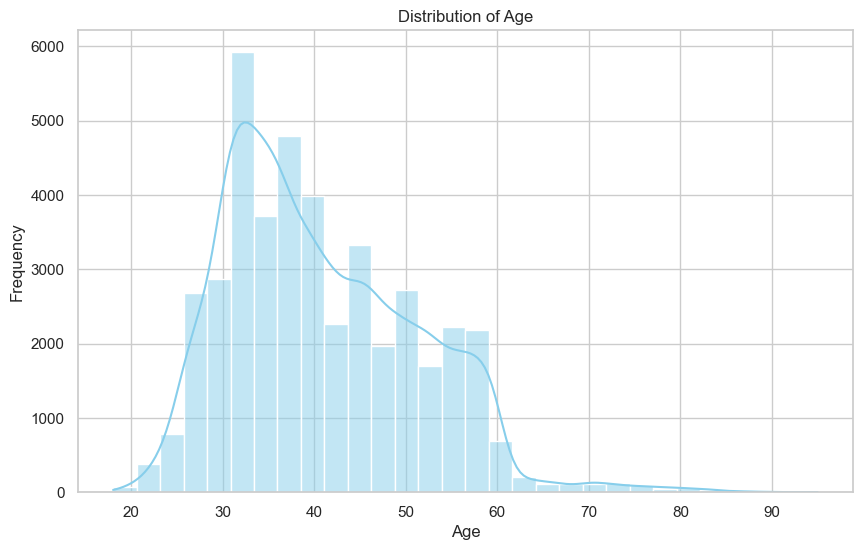

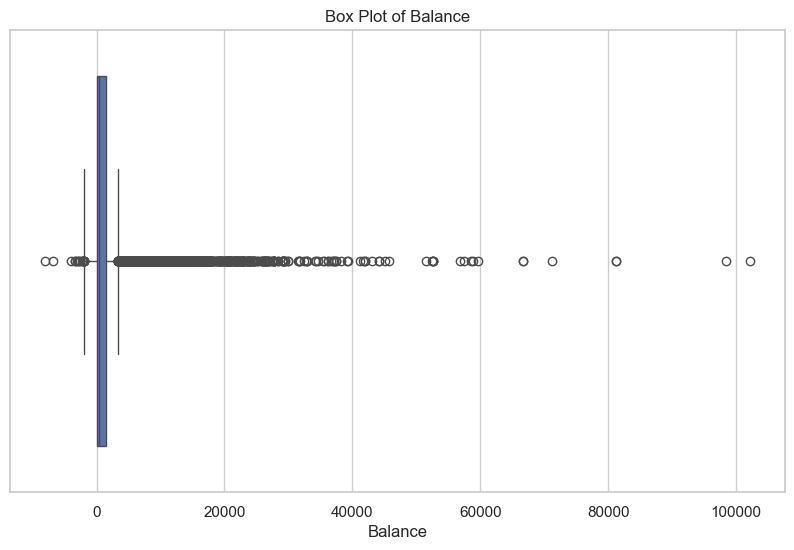

In [4]:
# Histogram of the 'age' column
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Boxplot for the 'balance' column
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['balance'])
plt.title('Box Plot of Balance')
plt.xlabel('Balance')
plt.show()


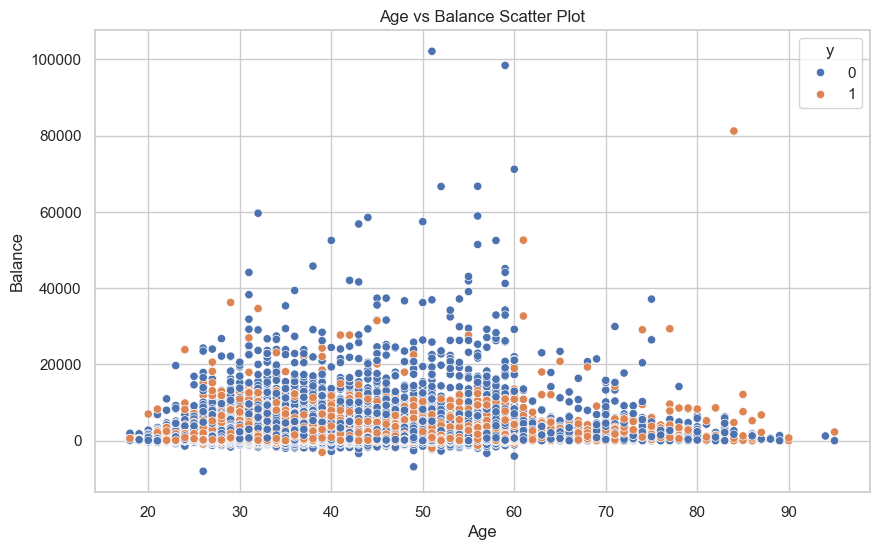

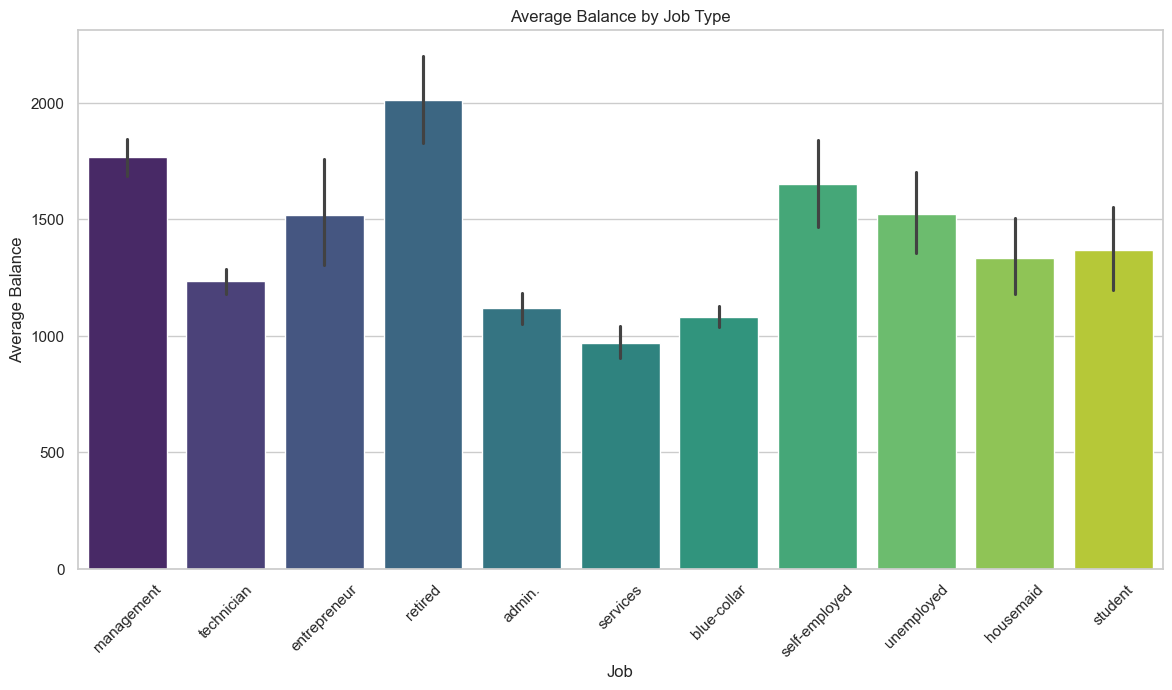

In [5]:
# Scatter plot between 'age' and 'balance'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='balance', data=df, hue='y')
plt.title('Age vs Balance Scatter Plot')
plt.xlabel('Age')
plt.ylabel('Balance')
plt.show()

# Bar chart of 'job' vs 'balance'
plt.figure(figsize=(14, 7))
sns.barplot(x='job', y='balance', hue='job', data=df, palette='viridis', legend=False)
plt.title('Average Balance by Job Type')
plt.xticks(rotation=45)
plt.xlabel('Job')
plt.ylabel('Average Balance')
plt.show()


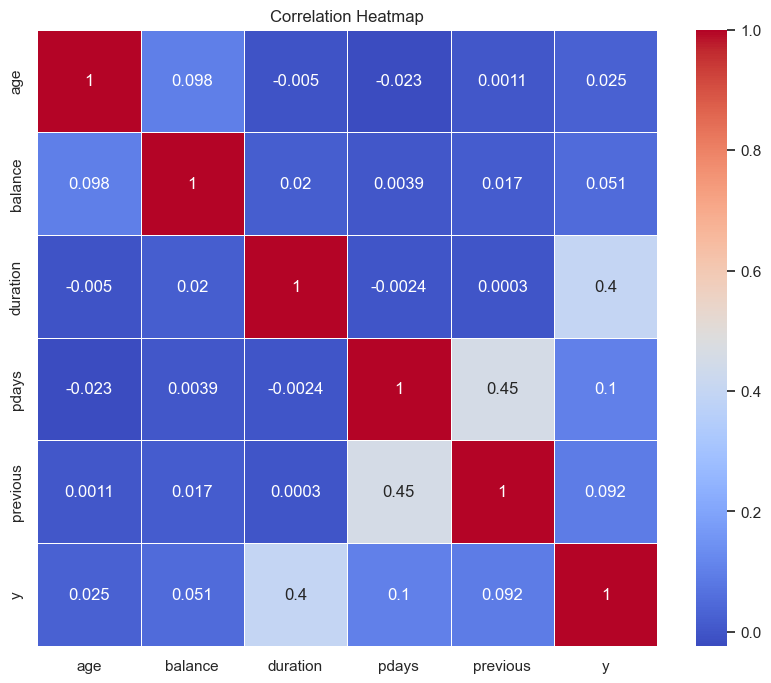

In [6]:
# Select only numeric columns for correlation matrix
numeric_df = df.select_dtypes(include=[np.number])  # np.number covers all numeric types
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


In [7]:
numeric_df = df.select_dtypes(include=[np.number])

# Now you can safely compute the descriptive statistics and correlation matrix
print("Basic Descriptive Statistics:")
print(numeric_df.describe())

print("\nCorrelation Coefficients:")
print(numeric_df.corr())

Basic Descriptive Statistics:
                age        balance      duration         pdays      previous  \
count  43193.000000   43193.000000  43193.000000  43193.000000  43193.000000   
mean      40.764082    1354.027342    258.323409     40.404070      0.584863   
std       10.512640    3042.103625    258.162006    100.420624      2.332672   
min       18.000000   -8019.000000      0.000000     -1.000000      0.000000   
25%       33.000000      71.000000    103.000000     -1.000000      0.000000   
50%       39.000000     442.000000    180.000000     -1.000000      0.000000   
75%       48.000000    1412.000000    318.000000     -1.000000      0.000000   
max       95.000000  102127.000000   4918.000000    871.000000    275.000000   

                  y  
count  43193.000000  
mean       0.116246  
std        0.320523  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        0.000000  
max        1.000000  

Correlation Coefficients:
               age   bal

In [8]:
print(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'month', 'duration', 'pdays', 'previous', 'poutcome',
       'y'],
      dtype='object')
